<a href="https://colab.research.google.com/github/davidebtt/chemical_pycode/blob/analytical-chemistry/GC_method_temperature_ramp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enter initial temperature (°C): 200
Enter initial hold time (minutes): 3
Enter number of ramps: 2
Ramp 1 - Target temperature (°C): 260
Ramp 1 - Ramp rate (°C/min): 2
Ramp 1 - Hold time at 260.0 °C (minutes): 2
Ramp 2 - Target temperature (°C): 290
Ramp 2 - Ramp rate (°C/min): 7
Ramp 2 - Hold time at 290.0 °C (minutes): 2

Generated GC Method:
Initial temperature: 200.0 °C
Initial hold: 3.0 minutes
Ramp 1: 2.0 °C/min to 260.0 °C
Hold 1: 2.0 minutes
Ramp 2: 7.0 °C/min to 290.0 °C
Hold 2: 2.0 minutes


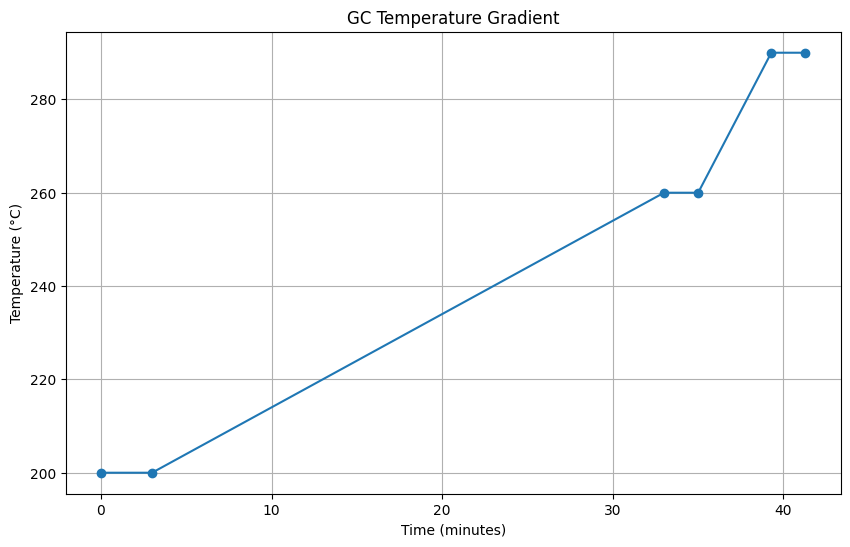

In [6]:
import matplotlib.pyplot as plt

def generate_gc_method(initial_temp, initial_hold_time, ramps, hold_times):
    """
    Generate a GC method with initial hold and multiple ramps/holds.

    Parameters:
    - initial_temp (float): Starting temperature (°C).
    - initial_hold_time (float): Hold time at initial temperature (minutes).
    - ramps (list of tuples): Each tuple is (target_temp, ramp_rate).
    - hold_times (list of floats): Hold time at each target_temp (minutes).

    Returns:
    - method (str): Description of the GC method.
    - temp_profile (list): Temperature points for plotting.
    - time_profile (list): Time points for plotting.
    """
    method = [f"Initial temperature: {initial_temp} °C"]
    temp_profile = [initial_temp]
    time_profile = [0]
    time = 0
    current_temp = initial_temp

    # Initial hold
    if initial_hold_time > 0:
        time += initial_hold_time
        temp_profile.append(initial_temp)
        time_profile.append(time)
        method.append(f"Initial hold: {initial_hold_time} minutes")

    # Ramps and holds
    for i, ((target_temp, ramp_rate), hold_time) in enumerate(zip(ramps, hold_times)):
        delta_temp = target_temp - current_temp
        ramp_time = abs(delta_temp) / ramp_rate
        time += ramp_time
        temp_profile.append(target_temp)
        time_profile.append(time)
        method.append(f"Ramp {i+1}: {ramp_rate} °C/min to {target_temp} °C")

        time += hold_time
        temp_profile.append(target_temp)
        time_profile.append(time)
        method.append(f"Hold {i+1}: {hold_time} minutes")

        current_temp = target_temp

    return "\n".join(method), temp_profile, time_profile


def plot_temperature_gradient(time_profile, temp_profile):
    plt.figure(figsize=(10, 6))
    plt.plot(time_profile, temp_profile, marker='o')
    plt.title("GC Temperature Gradient")
    plt.xlabel("Time (minutes)")
    plt.ylabel("Temperature (°C)")
    plt.grid()
    plt.show()


# --- User Inputs ---
initial_temp = float(input("Enter initial temperature (°C): "))
initial_hold_time = float(input("Enter initial hold time (minutes): "))
num_ramps = int(input("Enter number of ramps: "))

ramps = []
hold_times = []
for i in range(num_ramps):
    target_temp = float(input(f"Ramp {i+1} - Target temperature (°C): "))
    ramp_rate = float(input(f"Ramp {i+1} - Ramp rate (°C/min): "))
    hold_time = float(input(f"Ramp {i+1} - Hold time at {target_temp} °C (minutes): "))
    ramps.append((target_temp, ramp_rate))
    hold_times.append(hold_time)

# Generate and plot
method, temp_profile, time_profile = generate_gc_method(initial_temp, initial_hold_time, ramps, hold_times)
print("\nGenerated GC Method:\n" + method)
plot_temperature_gradient(time_profile, temp_profile)
